# Nobel-Announcement-Drift — a quantitative teardown 🔬
### Market-model CARs · one-sample *t* · random-October placebo · per-prize/sector cuts · horizon/entry-lag/era sweep · costs · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run a textbook event study: estimate each sector ETF's market-model beta on a trailing pre-event window, sum its abnormal returns vs SPY over the post-announcement window, and test the mean against a random-October placebo.

> ⚠️ **Not investment advice.** Real data: yfinance daily ETF closes, 72 Nobel science-prize announcements 2001-2024 (as-of 2026-06-30, prices fp `ea4f6fc0a551`, CAR table fp `e7c04bc8ac6d`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nobel_announcement_drift import data, strategy as st

H = 10

def load_real():
    """Cache-first real return panel + events (empty offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return None, None
    return st.daily_returns(px), data.nobel_events()

RETS, EVENTS = load_real()
HAVE_REAL = RETS is not None
print("real Nobel tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(EVENTS)} announcements, {EVENTS.year.min()}-{EVENTS.year.max()})")


real Nobel tape present: True (72 announcements, 2001-2024)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Mean 10-day CAR **-0.33%** (one-sample *t* **-1.36**, *n* 144) — insignificant, wrong sign; random-October placebo *p* **0.984**; only |*t*|≥2 cut is Medicine→health at *t* -2.33 (wrong sign); sign flips pre/post-2013. |
| **Tradability** | `MIRAGE` | Long-only sector ETF t0→t0+10: gross -0.33% → net -0.37% (2 bps/side, no borrow); negative at every horizon. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on the real tape there is no post-Nobel drift — the one significant move is the wrong way and the sign is era-unstable.

## 1 · The claim, steelmanned

Let $CAR_e$ be the market-model cumulative abnormal return of the mapped sector over $(t_0, t_0+H]$ for event $e$ (t0 = first session on/after the announcement).

- **H₁ (drift).** $\mathbb{E}[CAR] > 0$ at *t* ≥ 2 (the sector drifts up).
- **H₂ (special).** The Nobel-week mean CAR beats a random-October relocation (placebo *p* small).
- **H₃ (robustness).** The sign/size holds across horizons, entry lag and eras.
- **H₄ (net).** H₁ survives round-trip costs.

We find **H₁ rejected** (insignificant, wrong sign), **H₂ rejected** (placebo *p* 0.984 — random October is *better*), **H₃ rejected** (sign flips pre/post-2013), and **H₄ moot** (negative before costs).

## 2 · So what? — what rides on each answer

The content is the **why**. Genuine post-announcement drift (PEAD, keynote drift) is driven by an *information surprise* the market underreacts to. A Nobel prize is a backward-looking honour with **no cash-flow content** — there is no surprise for prices to underreact to, so the null is a *flat* CAR, and that is essentially what we get (slightly negative). Contrast the real drift family: [363 PEAD](../../363-pead-drift/), [299 Keynote-Drift](../../299-keynote-drift/), [515 Earnings-Announcement-Premium](../../515-earnings-announcement-premium/).

## 3 · How we'd know — the protocol

- **Abnormal returns.** Market model $r_{sec} - (\alpha + \beta\, r_{SPY})$, with $(\alpha,\beta)$ from a trailing 120-session window ending strictly before each day (rolling, no look-ahead).
- **CAR.** Sum the abnormal returns over $(t_0, t_0+H]$, $H=10$, for every mapped (prize, sector) pair.
- **Inference.** One-sample *t* of the mean CAR vs 0.
- **Placebo.** Relocate each event to a random trading day in the *same* October; *p* = share of draws whose mean CAR ≥ observed (2000 draws).
- **Robustness.** Sweep $H \in \{3,5,10,21\}$, entry at t0 vs t0+1, and a pre/post-2013 era split.
- **Costs.** Round-trip one-way cost per event (long-only ETF, no borrow).
- **Positive control.** A deterministic synthetic world with a planted post-event drift, averaged over 25 seeds (house rule).

Timing: the announcement is public and pre-scheduled, so entering at the first on/after-announcement close and measuring the *forward* window uses no future data. The same-close t0 fill is the one documented execution lag; a t0+1 variant is in the sweep.

## 4 · The teardown

### 4a · The headline CAR + placebo — H₁ & H₂

Mean 10-day CAR across all mapped events, its *t*, and the random-October null.

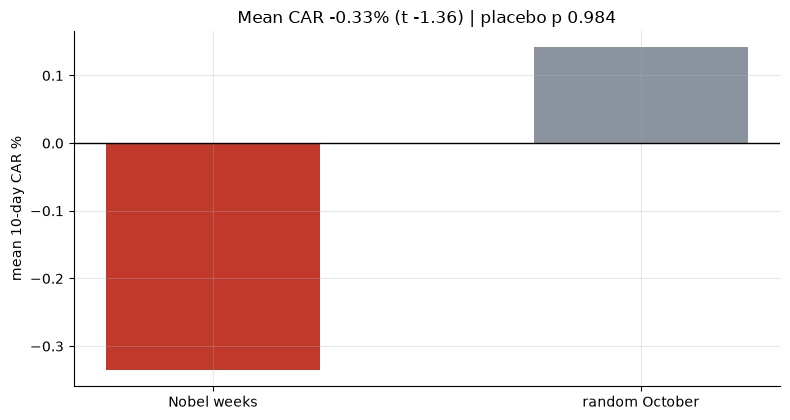

mean CAR -0.33% | t -1.36 | placebo mean +0.14% | p 0.984


In [2]:
mean_car, t, pval = -0.33, -1.36, 0.984
pmean = 0.14
if HAVE_REAL:
    tab = st.event_car_table(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizon=H)
    s = st.car_summary(tab); mean_car, t = s['mean_car']*100, s['t']
    pb = st.placebo_pvalue(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizon=H, n_draws=2000, seed=546)
    pmean, pval = pb['placebo_mean']*100, pb['p_value']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['Nobel weeks','random October'], [mean_car, pmean], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean 10-day CAR %')
ax.set_title(f'Mean CAR {mean_car:+.2f}% (t {t:+.2f}) | placebo p {pval:.3f}')
plt.tight_layout(); plt.show()
print(f'mean CAR {mean_car:+.2f}% | t {t:+.2f} | placebo mean {pmean:+.2f}% | p {pval:.3f}')

> 💡 In plain words: **H₁ and H₂ both rejected.** The mean CAR is **-0.33%** (*t* -1.36) and a random October week is *better* (placebo *p* 0.984). No attention bid.

### 4b · Per prize & per sector — where's the (non-)reaction?

Break the CAR out by prize and by sector ETF.

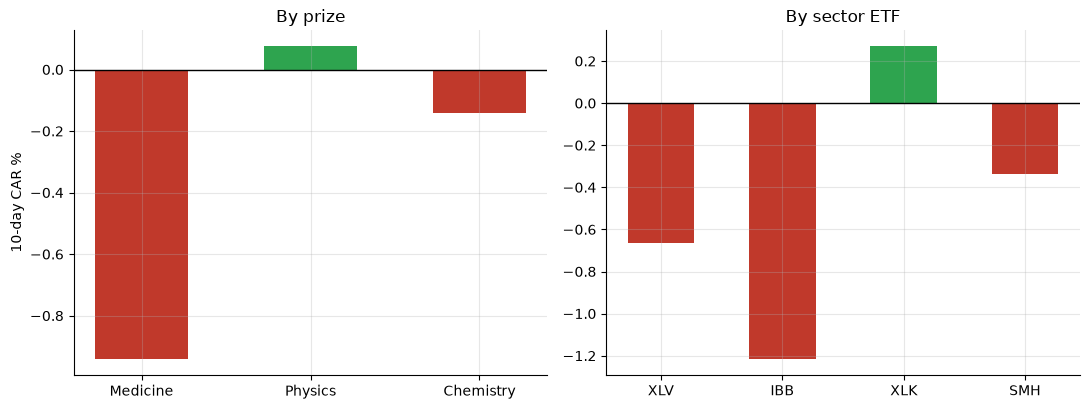

by prize:  [('medicine', -0.94, -2.33), ('physics', 0.08, 0.2), ('chemistry', -0.14, -0.29)]
by sector: [('XLV', -0.67, -2.5), ('IBB', -1.22, -1.58), ('XLK', 0.27, 1.1), ('SMH', -0.33, -0.6)]


In [3]:
prize_rows = [('medicine', 48, -0.94, -2.33), ('physics', 48, 0.08, 0.2), ('chemistry', 48, -0.14, -0.29)]
sect_rows = [('XLV', 'Medicine', 24, -0.67, -2.5), ('IBB', 'Medicine', 24, -1.22, -1.58), ('XLK', 'Physics/Chem', 48, 0.27, 1.1), ('SMH', 'Physics/Chem', 48, -0.33, -0.6)]
if HAVE_REAL:
    tab = st.event_car_table(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizon=H)
    prize_rows = [(p, len(tab[tab.prize==p]), st.car_summary(tab[tab.prize==p])['mean_car']*100,
                   st.car_summary(tab[tab.prize==p])['t']) for p in ['medicine','physics','chemistry']]
    smap = {'XLV':'Medicine','IBB':'Medicine','XLK':'Physics/Chem','SMH':'Physics/Chem'}
    sect_rows = [(sc, smap[sc], len(tab[tab.sector==sc]), st.car_summary(tab[tab.sector==sc])['mean_car']*100,
                  st.car_summary(tab[tab.sector==sc])['t']) for sc in ['XLV','IBB','XLK','SMH']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
pl = [r[0].title() for r in prize_rows]; pv = [r[2] for r in prize_rows]
a1.bar(pl, pv, color=[GREEN if v>0 else RED for v in pv], width=.55)
a1.axhline(0, c='k', lw=1); a1.set_title('By prize'); a1.set_ylabel('10-day CAR %')
sl = [r[0] for r in sect_rows]; sv = [r[3] for r in sect_rows]
a2.bar(sl, sv, color=[GREEN if v>0 else RED for v in sv], width=.55)
a2.axhline(0, c='k', lw=1); a2.set_title('By sector ETF')
plt.tight_layout(); plt.show()
print('by prize: ', [(r[0], round(r[2],2), round(r[3],2)) for r in prize_rows])
print('by sector:', [(r[0], round(r[3],2), round(r[4],2)) for r in sect_rows])

> 💡 In plain words: the only |*t*|≥2 cut is **XLV after Medicine at *t* -2.5** — pharma drifting *down*. Tech (XLK/SMH) after Physics/Chemistry is a coin-flip. No positive, significant reaction anywhere.

### 4c · Robustness — H₃ (horizon, entry lag, era)

Does anything positive survive a different holding length, a one-bar-later entry, or a different era?

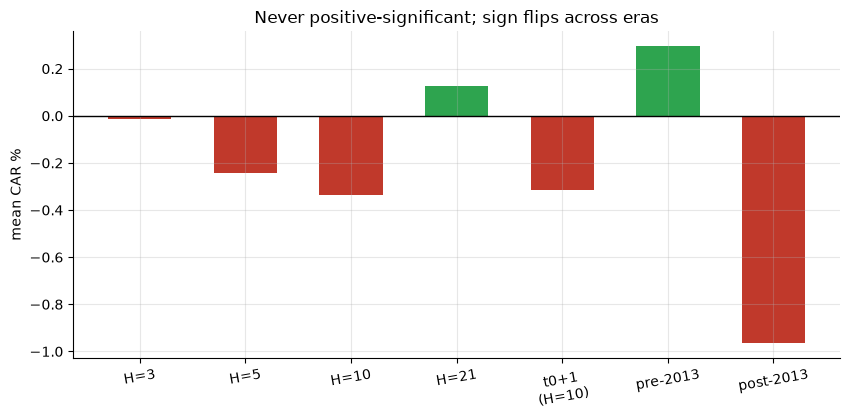

H= 3: -0.01% (t -0.07)
H= 5: -0.24% (t -1.42)
H=10: -0.33% (t -1.36)
H=21: +0.13% (t +0.32)
t0+1 H=10: -0.31% (t -1.26)
pre-2013: +0.30% (t +0.74) | post-2013: -0.97% (t -3.60)


In [4]:
hz = [(3, -0.01, -0.07), (5, -0.24, -1.42), (10, -0.33, -1.36), (21, 0.13, 0.32)]
lag1 = (-0.31, -1.26); era_pre = (0.3, 0.74); era_post = (-0.97, -3.6)
if HAVE_REAL:
    hs = st.horizon_sweep(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizons=(3,5,10,21))
    hz = [(h, hs.loc[h,'mean_car']*100, hs.loc[h,'t']) for h in (3,5,10,21)]
    l1 = st.horizon_sweep(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizons=(10,), entry_lag=1)
    lag1 = (l1.loc[10,'mean_car']*100, l1.loc[10,'t'])
    es = st.era_split(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizon=H, split_year=2013)
    era_pre = (es['pre']['mean_car']*100, es['pre']['t']); era_post = (es['post']['mean_car']*100, es['post']['t'])
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labs = [f'H={h}' for h,_,_ in hz] + ['t0+1\n(H=10)', 'pre-2013', 'post-2013']
vals = [v for _,v,_ in hz] + [lag1[0], era_pre[0], era_post[0]]
ax.bar(range(len(labs)), vals, color=[GREEN if v>0 else RED for v in vals], width=.6)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=10)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean CAR %')
ax.set_title('Never positive-significant; sign flips across eras')
plt.tight_layout(); plt.show()
for h,v,tt in hz: print(f'H={h:2d}: {v:+.2f}% (t {tt:+.2f})')
print(f't0+1 H=10: {lag1[0]:+.2f}% (t {lag1[1]:+.2f})')
print(f'pre-2013: {era_pre[0]:+.2f}% (t {era_pre[1]:+.2f}) | post-2013: {era_post[0]:+.2f}% (t {era_post[1]:+.2f})')

> 💡 In plain words: **H₃ rejected.** No horizon is positive-significant; the entry-lag variant is unchanged; and the era split *flips sign* (weakly + early, significantly − late, *t* -3.6). A sign that depends on the decade is not a signal.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (mean CAR -0.33%, *t* -1.36, wrong sign); H₂ rejected (placebo *p* 0.984); H₃ rejected (sign flips).
- **Tradability `MIRAGE`** — long-only sector ETF; gross -0.33% → net -0.37% (net *t* -1.53); negative at every horizon.

## 6 · Could you trade it? — costs

The trade is negative before costs; frictions only deepen the loss.

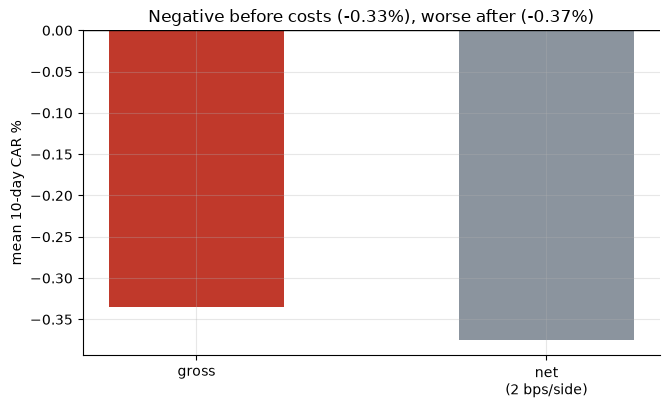

gross -0.33% -> net -0.37% (2 bps/side round-trip, long-only ETF)


In [5]:
gross, net = -0.33, -0.37
if HAVE_REAL:
    tab = st.event_car_table(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizon=H)
    nc = st.net_car(tab, cost_bps=2.0); gross, net = nc['gross']*100, nc['net']*100
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(['gross','net\n(2 bps/side)'], [gross, net], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean 10-day CAR %')
ax.set_title(f'Negative before costs ({gross:+.2f}%), worse after ({net:+.2f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}% -> net {net:+.2f}% (2 bps/side round-trip, long-only ETF)')

> 💡 In plain words: there's nothing to charge costs against — the buy-the-sector book *loses* before frictions. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real post-event drift of increasing strength and watch the CAR-*t* climb past +2 — averaged over 25 seeds so no single lucky seed can fake it.

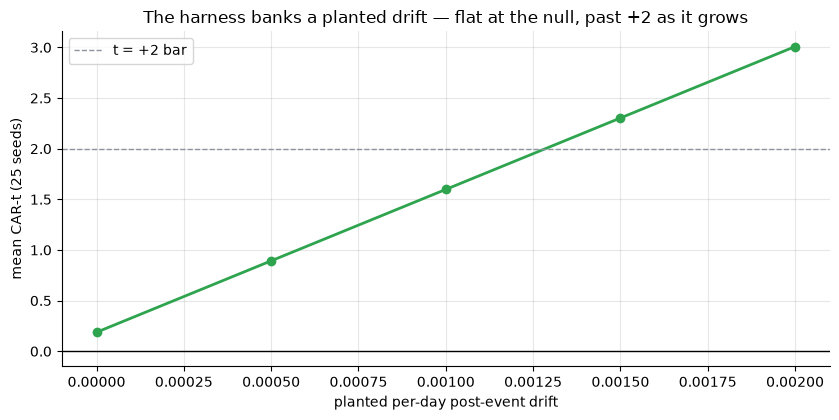

drift +0.0000 -> mean CAR-t +0.19
drift +0.0005 -> mean CAR-t +0.89
drift +0.0010 -> mean CAR-t +1.60
drift +0.0015 -> mean CAR-t +2.30
drift +0.0020 -> mean CAR-t +3.01


In [6]:
ctrl = [(0.0, 0.19), (0.0005, 0.89), (0.001, 1.6), (0.0015, 2.3), (0.002, 3.01)]
drifts = [c[0] for c in ctrl]
ts = [st.synthetic_mean_t(data, drift=d, horizon=H, n_seeds=25) for d in drifts]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(drifts, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted per-day post-event drift'); ax.set_ylabel('mean CAR-t (25 seeds)')
ax.set_title('The harness banks a planted drift — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for d, t in zip(drifts, ts): print(f'drift {d:+.4f} -> mean CAR-t {t:+.2f}')

The CAR-*t* is ≈ 0 at the null and rises past +2 as the planted drift grows — so the engine is a faithful detector. The flat/negative real-tape result is therefore the **absence of an effect**, not a broken test: a Nobel prize carries no cash-flow surprise, so the related sector doesn't drift. For real announcement drifts, see [363 PEAD](../../363-pead-drift/) and [299 Keynote-Drift](../../299-keynote-drift/).